## EDA And Feature Engineering Of Google Play Store Dataset

#### 1) Problem statement:
- Today, 1.85 million different apps are available for users to download.
- Android users have even more from which to choose, with 2.56 million available through the Google Play Store.
- These apps have come to play a huge role in the way we live our lives today.
- Our Objective is to find:
  * The Most Popular Category
  * The App with largest number of installs
  * The App with largest size etc.

## Feature Information
1. App :- Name of the App
2. Category :- Category under which the App falls.
3. Rating :- Application's rating on playstore
4. Reviews :- Number of reviews of the App.
5. Size :- Size of the App.
6. Install :- Number of Installs of the App
7. Type :- If the App is free/paid
8. Price :- Price of the app (0 if it is Free)
9. Content Rating :- Appropiate Target Audience of the App.
10. Genres:- Genre under which the App falls.
11. Last Updated :- Date when the App was last updated
12. Current Ver :- Current Version of the Application
13. Android Ver :- Minimum Android Version required to run the App

### Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

### Loading dataset

In [2]:
df = pd.read_csv("Google-Playstore-Data/googleplaystore.csv")

### Overview of the dataset

In [3]:
df.shape

(10841, 14)

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [6]:
df.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated',
       'Current Ver', 'Android Ver'],
      dtype='str')

In [7]:
df.drop(labels='Unnamed: 0',
       axis=1,
       inplace=True)

### Data Cleaning

In [8]:
# checking for missing values
df.isnull().any()

App               False
Category          False
Rating             True
Reviews           False
Size              False
Installs          False
Type               True
Price             False
Content Rating     True
Genres            False
Last Updated      False
Current Ver        True
Android Ver        True
dtype: bool

In [9]:
# finding total no. of missing values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

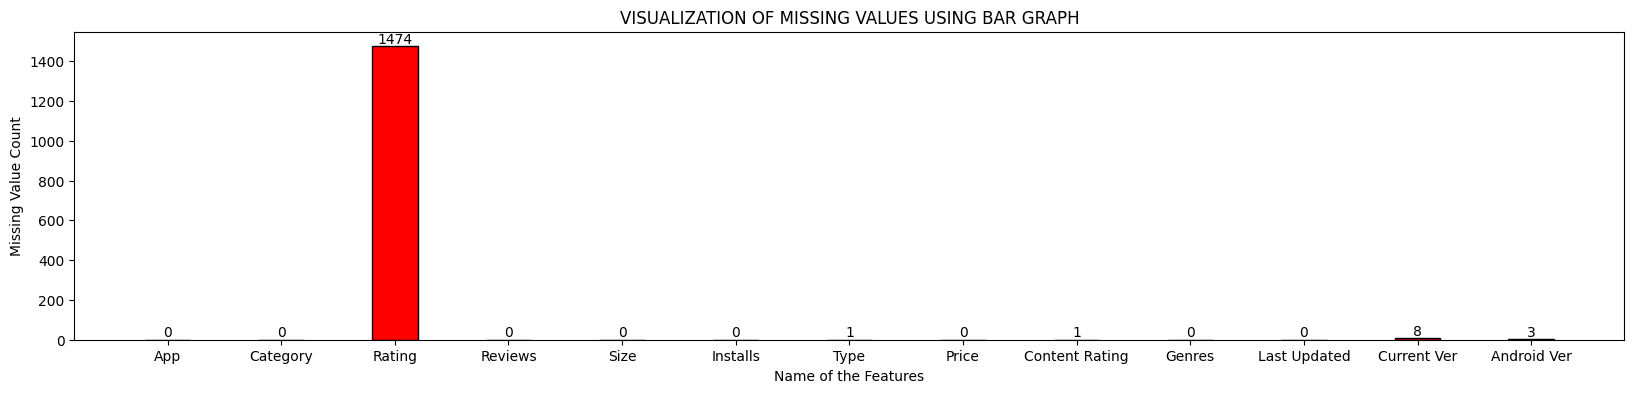

In [10]:
# visualization of missing values with help of bar charts
plt.figure(figsize=(20,4))
bars = plt.bar(x=df.isnull().sum().index,
       height=df.isnull().sum().values,
       edgecolor='black',
       width=0.4,
       color='red')
plt.bar_label(bars,
              labels=df.isnull().sum().values,
              label_type='edge')
plt.xlabel('Name of the Features')
plt.ylabel('Missing Value Count')
plt.title('VISUALIZATION OF MISSING VALUES USING BAR GRAPH')
plt.savefig("reports/missing_value_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# brief overview of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


### So, we have to clean the numerical columns and convert them into integer or float type, which ever is required

### As, we can see, 'review' should be an integer type column. Lets clean that column.

In [12]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [13]:
df['Reviews'].unique()

<StringArray>
[   '159',    '967',  '87510', '215644',    '167',    '178',  '36815',
  '13791',    '121',  '13880',
 ...
   '2036',  '56496', '376223',    '785',   '5775',    '885',  '88486',
    '603',   '1195', '398307']
Length: 6002, dtype: str

In [14]:
# checking for numerical strings
print(df['Reviews'].str.isnumeric().sum())

10840


In [15]:
# actual length of the series data
len(df['Reviews'])

10841

In [16]:
len(df['Reviews']) - (df['Reviews'].str.isnumeric().sum())

np.int64(1)

#### So, there is one value in the 'Review' column which is not numeric

In [17]:
# checking that non-numeric element
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,11-Feb-18,1.0.19,4.0 and up,NaN


In [18]:
# deleting that row
df_filtered = df.drop(df.index[10472])
df_filtered = df_filtered.reset_index(drop=True)

In [19]:
# checking
df_filtered[~df_filtered['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [20]:
# converting datatype to int
df_filtered['Reviews'] = df_filtered['Reviews'].astype(int)

In [21]:
df_filtered.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up


### As we can see, 'size' should be a float type column. Lets clean that column.

In [22]:
# checking for unique values
df_filtered['Size'].unique()

<StringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

#### So, we can conclude that, there are mainly 5 types of format available. e.g.
- '19M'
- '3.1M'
- '899k'
- '8.5k'
- 'Varies with device'
#### We are going to convert all numerical formats into 'k'-scale:
- '19M' --> 19000
- '3.1M' --> 3100
- '899k' --> 899
- '8.5k' --> 8.5
#### We can replce 'Varies with device' with 'np.nan'

In [23]:
def convert(x):
    if 'M' in x:
        x = float(x.replace('M',''))*1000
        return x
    elif 'k' in x:
        x = float(x.replace('k',''))
        return x
    else:
        return np.nan

In [24]:
df_filtered['Size'] = df_filtered['Size'].apply(lambda x: convert(x))

In [25]:
df_filtered.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


### As we can see, 'Installs' should be an integer type column. Let us clean that column.

In [26]:
chars_to_remove = [',','+']
for item in chars_to_remove:
    df_filtered['Installs'] = df_filtered['Installs'].str.replace(item, '')

In [27]:
df_filtered['Installs'] = df_filtered['Installs'].astype(int)

In [28]:
df_filtered

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0,Everyone,Education,25-Jul-17,1.48,4.1 and up
10836,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.0,100,Free,0,Everyone,Education,6-Jul-18,1,4.1 and up
10837,Parkinson Exercices FR,MEDICAL,NaN,3,9500.0,1000,Free,0,Everyone,Medical,20-Jan-17,1,2.2 and up
10838,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0,Mature 17+,Books & Reference,19-Jan-15,Varies with device,Varies with device


In [29]:
# brief description of the dataset
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(2), int64(2), str(9)
memory usage: 1.1 MB


### As we can see, the 'Price' should be a float column. Lets clean that column.

In [30]:
# checking unique values
df_filtered['Price'].unique()

<StringArray>
[       '0',   '$4.99 ',   '$3.99 ',   '$6.99 ',   '$1.49 ',   '$2.99 ',
   '$7.99 ',   '$5.99 ',   '$3.49 ',   '$1.99 ',   '$9.99 ',   '$7.49 ',
   '$0.99 ',   '$9.00 ',   '$5.49 ',  '$10.00 ',  '$24.99 ',  '$11.99 ',
  '$79.99 ',  '$16.99 ',  '$14.99 ',   '$1.00 ',  '$29.99 ',  '$12.99 ',
   '$2.49 ',  '$10.99 ',   '$1.50 ',  '$19.99 ',  '$15.99 ',  '$33.99 ',
  '$74.99 ',  '$39.99 ',   '$3.95 ',   '$4.49 ',   '$1.70 ',   '$8.99 ',
   '$2.00 ',   '$3.88 ',  '$25.99 ', '$399.99 ',  '$17.99 ', '$400.00 ',
   '$3.02 ',   '$1.76 ',   '$4.84 ',   '$4.77 ',   '$1.61 ',   '$2.50 ',
   '$1.59 ',   '$6.49 ',   '$1.29 ',   '$5.00 ',  '$13.99 ', '$299.99 ',
 '$379.99 ',  '$37.99 ',  '$18.99 ', '$389.99 ',  '$19.90 ',   '$8.49 ',
   '$1.75 ',  '$14.00 ',   '$4.85 ',  '$46.99 ', '$109.99 ', '$154.99 ',
   '$3.08 ',   '$2.59 ',   '$4.80 ',   '$1.96 ',  '$19.40 ',   '$3.90 ',
   '$4.59 ',  '$15.46 ',   '$3.04 ',   '$4.29 ',   '$2.60 ',   '$3.28 ',
   '$4.60 ',  '$28.99 ',   '$2.95 ', 

In [31]:
df_filtered['Price'].apply(lambda x: float(x.strip().replace('$',''))).unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [32]:
df_filtered['Price'] = df_filtered['Price'].apply(lambda x: float(x.strip().replace('$','')))

In [33]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 1.1 MB


### checking for duplicate apps and deleting them, because duplicate apps will not provide any useful information during the anlysis.

In [34]:
df_filtered['App'].nunique()

9659

In [35]:
# checking duplicated apps
df_filtered.duplicated(subset=['App']).value_counts()

False    9659
True     1181
Name: count, dtype: int64

In [36]:
df_filtered = df_filtered.drop_duplicates(subset=['App'], keep='first')

### converting the 'Last Updated' column into datetime format and also storing the date, month and year into separate columns.

In [37]:
df_filtered['Last Updated'].unique()

<StringArray>
[ '7-Jan-18', '15-Jan-18',  '1-Aug-18',  '8-Jun-18', '20-Jun-18', '26-Mar-17',
 '26-Apr-18', '14-Jun-18', '20-Sep-17',  '3-Jul-18',
 ...
 '23-Nov-15', '17-Jun-12', '27-Feb-15', '18-Dec-13',  '6-Feb-12', '25-Nov-14',
 '19-May-16', '20-Jan-14', '16-Feb-14', '23-Mar-14']
Length: 1377, dtype: str

In [38]:
pd.to_datetime(df_filtered['Last Updated'],
              format='%d-%b-%y')

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10835   2017-07-25
10836   2018-07-06
10837   2017-01-20
10838   2015-01-19
10839   2018-07-25
Name: Last Updated, Length: 9659, dtype: datetime64[us]

In [39]:
df_filtered['Last Updated'] = pd.to_datetime(df_filtered['Last Updated'],
                                             format='%d-%b-%y')
df_filtered['Day_updated'] = df_filtered['Last Updated'].dt.day
df_filtered['Month_updated'] = df_filtered['Last Updated'].dt.month
df_filtered['Year_updated'] = df_filtered['Last Updated'].dt.year

In [40]:
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 9659 entries, 0 to 10839
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   str           
 1   Category        9659 non-null   str           
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            8432 non-null   float64       
 5   Installs        9659 non-null   int64         
 6   Type            9658 non-null   str           
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   str           
 9   Genres          9659 non-null   str           
 10  Last Updated    9659 non-null   datetime64[us]
 11  Current Ver     9651 non-null   str           
 12  Android Ver     9657 non-null   str           
 13  Day_updated     9659 non-null   int32         
 14  Month_updated   9659 non-null   int32         
 15  Year_updated    965

In [41]:
df_filtered.drop(labels='Last Updated',
                axis=1,
                inplace=True)

### Exploratory Data Analysis

In [42]:
categorical_feature = [feature for feature in df_filtered.columns if (df_filtered[feature].dtype == 'str')]
numeric_features = [feature for feature in df_filtered.columns if feature not in categorical_feature]

# print columns
print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features: {}".format(len(categorical_feature), categorical_feature))

We have 8 numerical features: ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day_updated', 'Month_updated', 'Year_updated']
We have 7 categorical features: ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


#### Categorical Columns

In [43]:
# Proportion of count data in each categorical column
for col in categorical_feature:
    print('_________________________________')
    print(df[col].value_counts(normalize=True)*100)

_________________________________
App
ROBLOX                                               0.083018
CBS Sports App - Scores, News, Stats & Watch Live    0.073794
Duolingo: Learn Languages Free                       0.064570
Candy Crush Saga                                     0.064570
8 Ball Pool                                          0.064570
                                                       ...   
Sya9a Maroc - FR                                     0.009224
Fr. Mike Schmitz Audio Teachings                     0.009224
Parkinson Exercices FR                               0.009224
The SCP Foundation DB fr nn5n                        0.009224
iHoroscope - 2018 Daily Horoscope & Astrology        0.009224
Name: proportion, Length: 9660, dtype: float64
_________________________________
Category
FAMILY                 18.190204
GAME                   10.552532
TOOLS                   7.776035
MEDICAL                 4.270824
BUSINESS                4.243151
PRODUCTIVITY            3

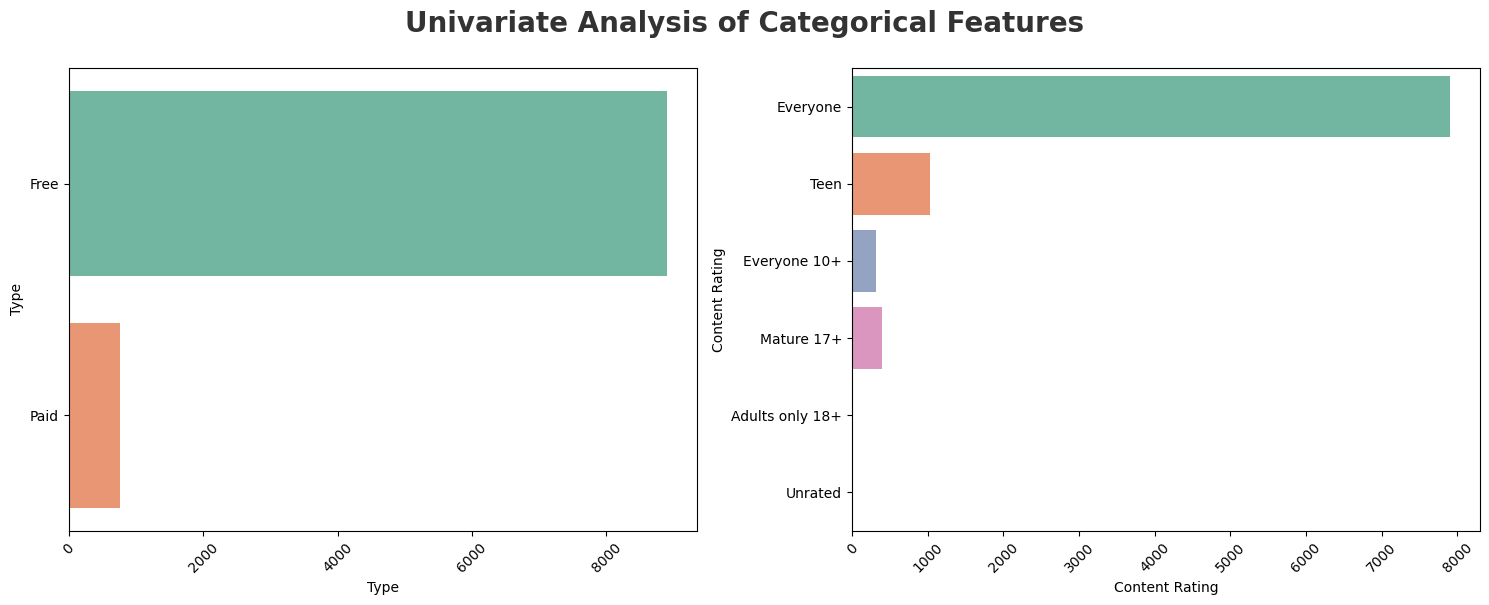

In [44]:
# # Proportion of count data on categorical columns
plt.figure(figsize=(15, 6))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)
category = [ 'Type', 'Content Rating']

for i,col in enumerate(category):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=df_filtered[col], palette="Set2")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.savefig("reports/Univariate_Analysis_of_Categorical_Features.png", dpi=300, bbox_inches="tight");

#### Numerical Columns

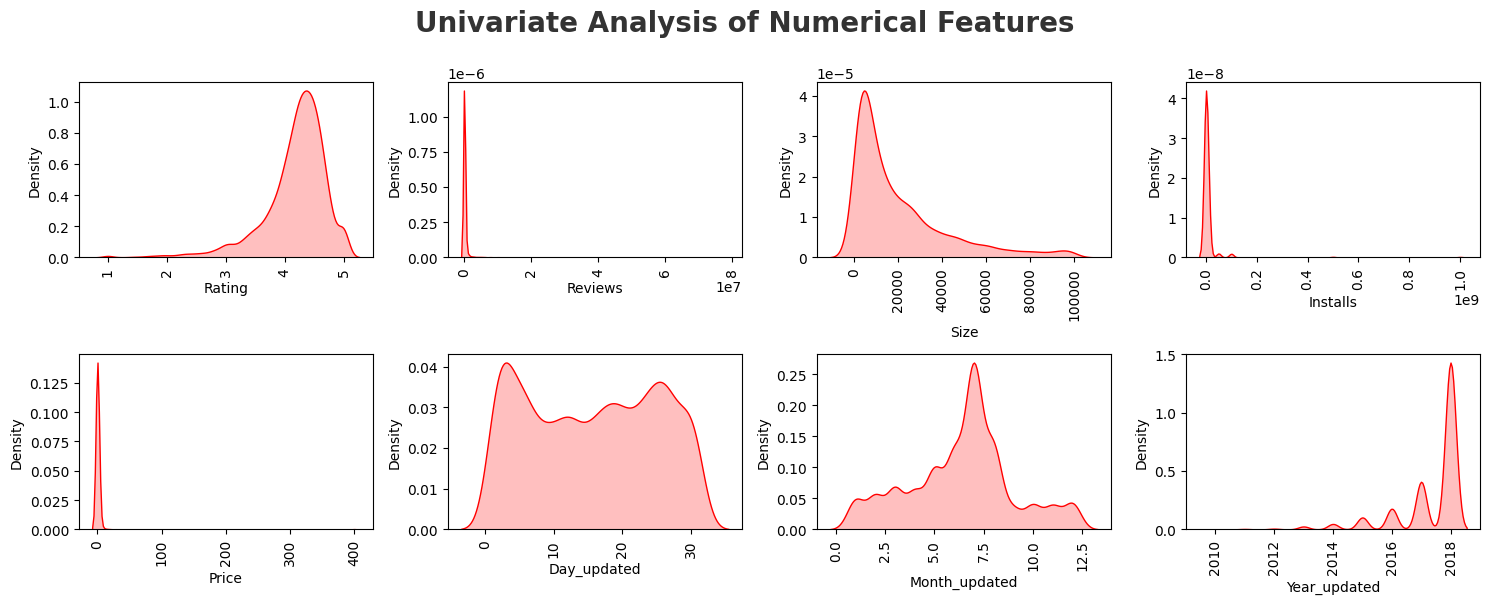

In [45]:
# Proportion of count data on numerical columns
plt.figure(figsize=(15, 6))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1)

for i,col in enumerate(numeric_features):
    plt.subplot(2, 4, i+1)
    sns.kdeplot(data=df_filtered[col],shade=True, color='r')
    plt.xlabel(col)
    plt.xticks(rotation=90)
    plt.tight_layout()
plt.savefig("reports/Univariate_Analysis_of_Numerical_Features.png", dpi=300, bbox_inches="tight");

### Observation
- Rating and year both are left skewed
- Reviews, Size, Installs, Price are right skewed

# Which is the most popular app category?

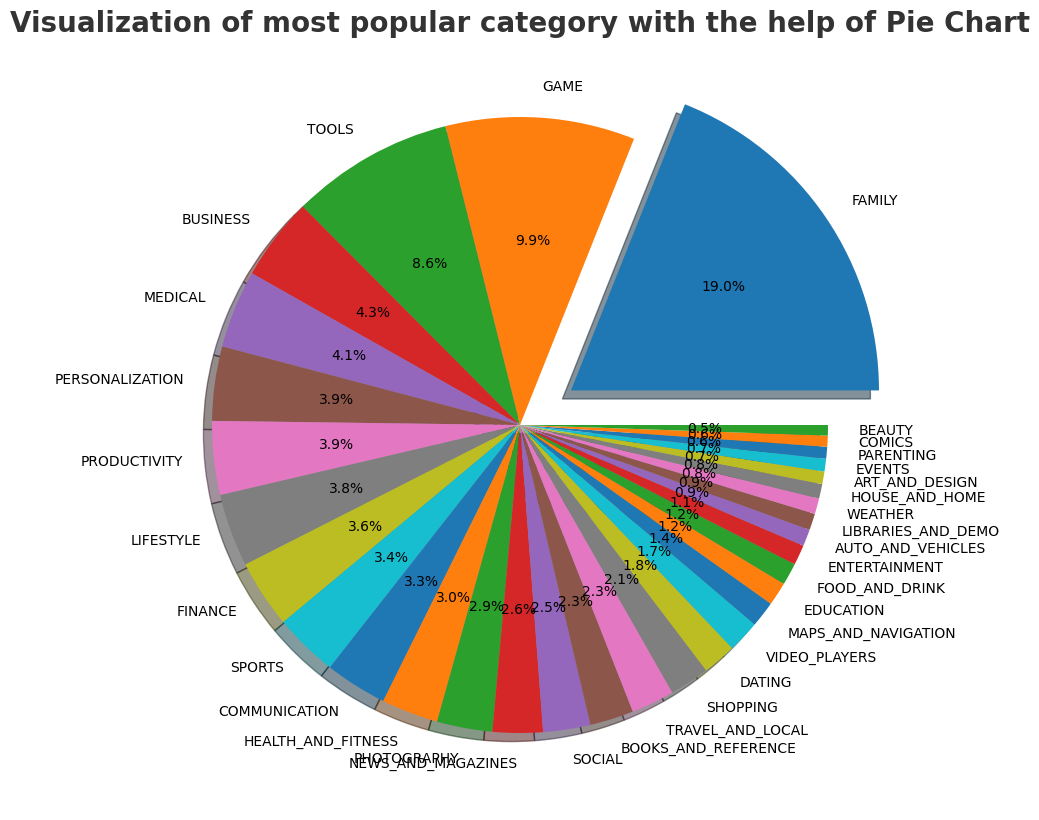

In [46]:
labels = df_filtered['Category'].value_counts().index
values = df_filtered['Category'].value_counts().values
explode = [0.2]
for _ in range(len(labels)-1):
    explode.append(0)

plt.figure(figsize=(10, 10))
plt.pie(values,explode=explode,labels=labels,autopct="%1.1f%%",shadow=True)
plt.title('Visualization of most popular category with the help of Pie Chart', fontsize=20, fontweight='bold', loc='center', alpha=0.8)
plt.savefig("reports/most_popular_categories.png", dpi=300, bbox_inches="tight")
plt.show()

## Observation:
1. The most popular category is "Family"
2. Three least popular categories are: "Beauty", "Comics" and "Parenting"

# What are the top 10 most popular app categories?

In [47]:
category_df = pd.DataFrame({'App_categories': df_filtered['Category'].value_counts().index,
                           'Count': df_filtered['Category'].value_counts().values,
                           'Percentage': df_filtered['Category'].value_counts(normalize=True).values.round(4)*100})
category_df.head(10)

,App_categories,Count,Percentage
0,FAMILY,1832,18.97
1,GAME,959,9.93
2,TOOLS,827,8.56
3,BUSINESS,420,4.35
4,MEDICAL,395,4.09
5,PERSONALIZATION,376,3.89
6,PRODUCTIVITY,374,3.87
7,LIFESTYLE,369,3.82
8,FINANCE,345,3.57
9,SPORTS,325,3.36


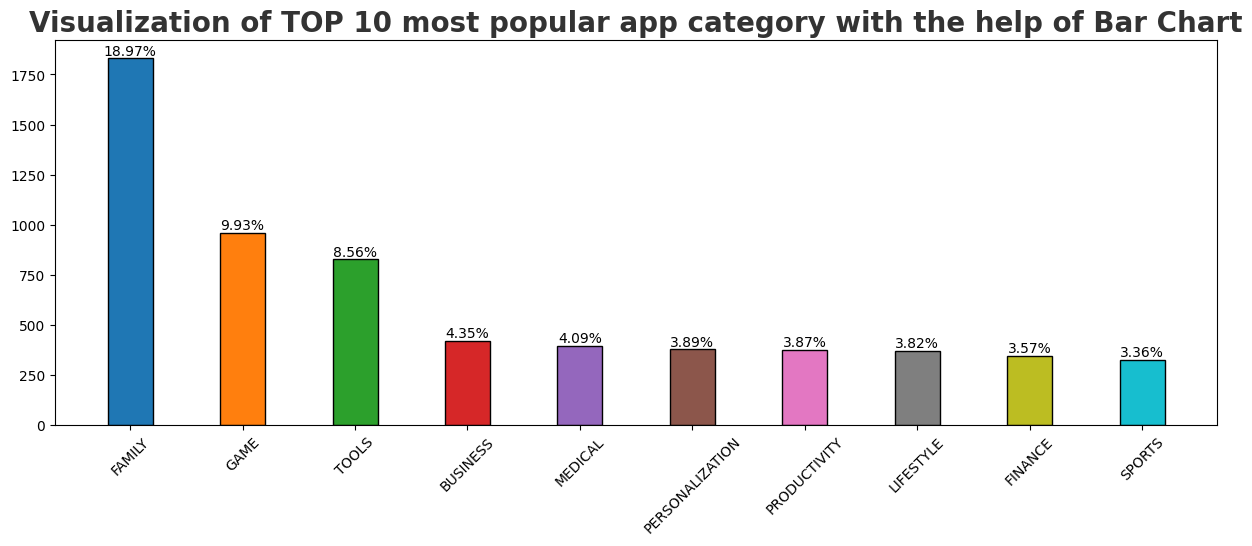

In [48]:
x_labels = category_df.loc[:9, 'App_categories']
values = category_df.loc[:9, 'Count']
colors = plt.get_cmap("tab10").colors[:len(x_labels)]
labels = [f"{round(p,2)}%" for p in category_df.loc[:9, 'Percentage']]

plt.figure(figsize=(15, 5))
bars = plt.bar(x=x_labels,
       height=values,
       edgecolor='black',
       width=0.4,
       color=colors)
plt.bar_label(bars,
              labels=labels,
              label_type='edge')
plt.xticks(rotation=45)
plt.title('Visualization of TOP 10 most popular app category with the help of Bar Chart',
          fontsize=20, fontweight='bold', loc='center', alpha=0.8)
plt.savefig("reports/Tpo_10_popular_apps.png", dpi=300, bbox_inches="tight");
plt.show()

# Which category has largest number of installation?

In [49]:
install_df = pd.DataFrame({'category': df_filtered.groupby(by='Category')['Installs'].aggregate('sum').index,
                          'Total_installs': df_filtered.groupby(by='Category')['Installs'].aggregate('sum').values})
install_df.sort_values(by='Total_installs', ascending=False, inplace=True)
install_df.reset_index(drop=True, inplace=True)
install_df.head(10)

,category,Total_installs
0,GAME,13878924415
1,COMMUNICATION,11038276251
2,TOOLS,8001771915
3,PRODUCTIVITY,5793091369
4,SOCIAL,5487867902
5,PHOTOGRAPHY,4649147655
6,FAMILY,4427941505
7,VIDEO_PLAYERS,3926902720
8,TRAVEL_AND_LOCAL,2894887146
9,NEWS_AND_MAGAZINES,2369217760


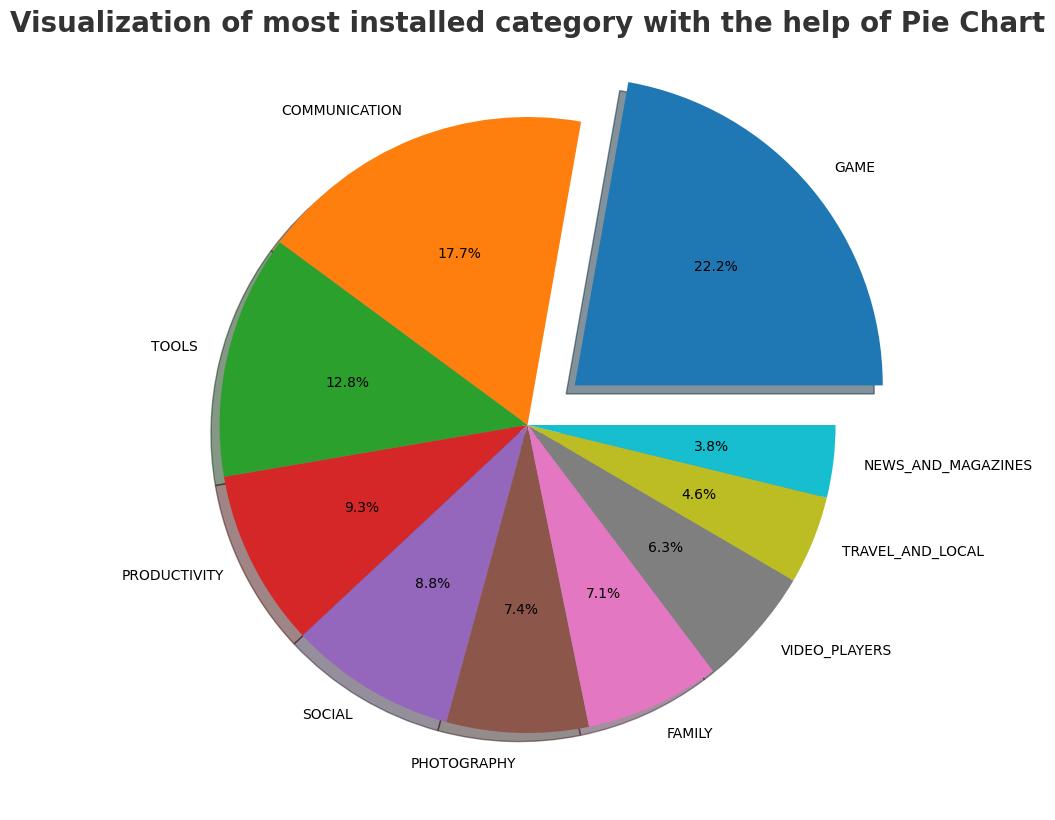

In [50]:
labels = list(install_df.loc[0:9, 'category'])
values = list(install_df.loc[0:9, 'Total_installs'])
explode = [0.2]
for _ in range(len(labels)-1):
    explode.append(0)

plt.figure(figsize=(10, 10))
plt.pie(values,explode=explode,labels=labels,autopct="%1.1f%%",shadow=True)
plt.title('Visualization of most installed category with the help of Pie Chart', fontsize=20, fontweight='bold', loc='center', alpha=0.8)
plt.savefig("reports/Most_installed_categories.png", dpi=300, bbox_inches="tight");
plt.show()

# Which are the top 5 most installed Apps in each of the 10 most popular categories?

In [51]:
# 10 most popular categories
popular_cat = list(category_df.loc[:9,'App_categories'])

In [52]:
data = {"Category":[], "App": [], "Installs": []}

for cat in popular_cat:
    print('____________CATEGORY: {}________________'.format(cat))
    print(df_filtered[df_filtered['Category']==cat].groupby(by='App')['Installs'].sum().sort_values(ascending=False)[:5])
    app_list = list(df_filtered[df_filtered['Category']==cat].groupby(by='App')['Installs'].sum().sort_values(ascending=False)[:5].index)
    values = list(df_filtered[df_filtered['Category']==cat].groupby(by='App')['Installs'].sum().sort_values(ascending=False)[:5].values)
    for i,app in enumerate(app_list):
        data["Category"].append(cat)
        data["App"].append(app)
        data["Installs"].append(values[i])

____________CATEGORY: FAMILY________________
App
Bubble Witch 2 Saga       100000000
Where's My Water? Free    100000000
Hay Day                   100000000
Talking Tom Cat           100000000
Tom Loves Angela          100000000
Name: Installs, dtype: int64
____________CATEGORY: GAME________________
App
Subway Surfers      1000000000
Pou                  500000000
My Talking Tom       500000000
Temple Run 2         500000000
Candy Crush Saga     500000000
Name: Installs, dtype: int64
____________CATEGORY: TOOLS________________
App
Google                                                1000000000
Clean Master- Space Cleaner & Antivirus                500000000
Security Master - Antivirus, VPN, AppLock, Booster     500000000
Google Translate                                       500000000
Gboard - the Google Keyboard                           500000000
Name: Installs, dtype: int64
____________CATEGORY: BUSINESS________________
App
File Commander - File Manager/Explorer                1000

In [53]:
new_df = pd.DataFrame(data)
new_df

,Category,App,Installs
0,FAMILY,Bubble Witch 2 Saga,100000000
1,FAMILY,Where's My Water? Free,100000000
2,FAMILY,Hay Day,100000000
3,FAMILY,Talking Tom Cat,100000000
4,FAMILY,Tom Loves Angela,100000000
5,GAME,Subway Surfers,1000000000
6,GAME,Pou,500000000
7,GAME,My Talking Tom,500000000
8,GAME,Temple Run 2,500000000
9,GAME,Candy Crush Saga,500000000


In [54]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [58]:
fig = px.sunburst(new_df, 
                  path=["Category", "App"],
                  values="Installs",
                  color="Category")
fig.update_layout( width=900, height=900,
                 title={ "text": "App Installs by Category", 
                         "x": 0.5, # center 
                         "y": 0.95, # vertical position 
                         "xanchor": "center", 
                         "yanchor": "top", 
                         "font": dict(size=24, color="darkblue", family="Arial")
                       }
                 )
fig.write_image("reports/app_installed_by_category.png",scale=2)
fig.show()

# How many apps are there on Google Play Store which get 5 ratings?

In [56]:
df_filtered[df_filtered['Rating']==5].reset_index(drop=True)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day_updated,Month_updated,Year_updated
0,Hojiboy Tojiboyev Life Hacks,COMICS,5.0,15,37000.0,1000,Free,0.0,Everyone,Comics,2,4.0.3 and up,26,6,2018
1,American Girls Mobile Numbers,DATING,5.0,5,4400.0,1000,Free,0.0,Mature 17+,Dating,3,4.0.3 and up,17,7,2018
2,Awake Dating,DATING,5.0,2,70000.0,100,Free,0.0,Mature 17+,Dating,2.2.9,4.4 and up,24,7,2018
3,Spine- The dating app,DATING,5.0,5,9300.0,500,Free,0.0,Teen,Dating,4,4.0.3 and up,14,7,2018
4,Girls Live Talk - Free Text and Video Chat,DATING,5.0,6,5000.0,100,Free,0.0,Mature 17+,Dating,8.2,4.0.3 and up,1,8,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,Mad Dash Fo' Cash,GAME,5.0,14,16000.0,100,Free,0.0,Everyone,Arcade,2.5a,4.1 and up,19,6,2017
267,GKPB FP Online Church,LIFESTYLE,5.0,32,7900.0,1000,Free,0.0,Everyone,Lifestyle,0.7.1,4.4 and up,31,12,2017
268,Monster Ride Pro,GAME,5.0,1,24000.0,10,Free,0.0,Everyone,Racing,2,2.3 and up,5,3,2018
269,Fr. Daoud Lamei,FAMILY,5.0,22,8600.0,1000,Free,0.0,Teen,Education,3.8.0,4.1 and up,27,6,2018


In [57]:
print("No. of apps: {}".format(len(df_filtered[df_filtered['Rating']==5])))

No. of apps: 271
